# 第6章: 連続型分布と標本分布

## 学習目標
- 主要な連続型分布の性質を理解する
- 正規分布から派生する分布（χ²、t、F分布）を理解する
- 標本分布の概念を理解する

## 📋 学習メタ情報

### 学習目標
（既存の学習目標を活用）

### 推定学習時間
**100〜130分**

### 難易度
**★★★☆☆** (5段階中3)

---

## 🎯 なぜこの章を学ぶのか？

連続型分布は、測定データ（身長、温度、時間など）のモデリングに使われます。正規分布は自然界で最も頻繁に現れ、指数分布は待ち時間、ガンマ分布は累積時間、ベータ分布は確率のモデリングに使われます。

### 実世界での応用

**製品の寿命モデリング**: 指数分布・ワイブル分布で故障時間を予測し、保守計画を立案

**ベイズ統計の事前分布**: ベータ分布を成功確率の事前分布として使用

**待ち行列理論**: 指数分布で顧客の到着間隔をモデリング

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

## 6.1 正規分布（ガウス分布）

### 定義
$$f(x) = \frac{1}{\sqrt{2\pi}\sigma} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

### 性質
- $E[X] = \mu$, $Var(X) = \sigma^2$
- $M_X(t) = \exp(\mu t + \sigma^2 t^2 / 2)$
- 線形変換で閉じている: $aX + b \sim N(a\mu + b, a^2\sigma^2)$
- 独立な正規変数の和: $X + Y \sim N(\mu_X + \mu_Y, \sigma_X^2 + \sigma_Y^2)$

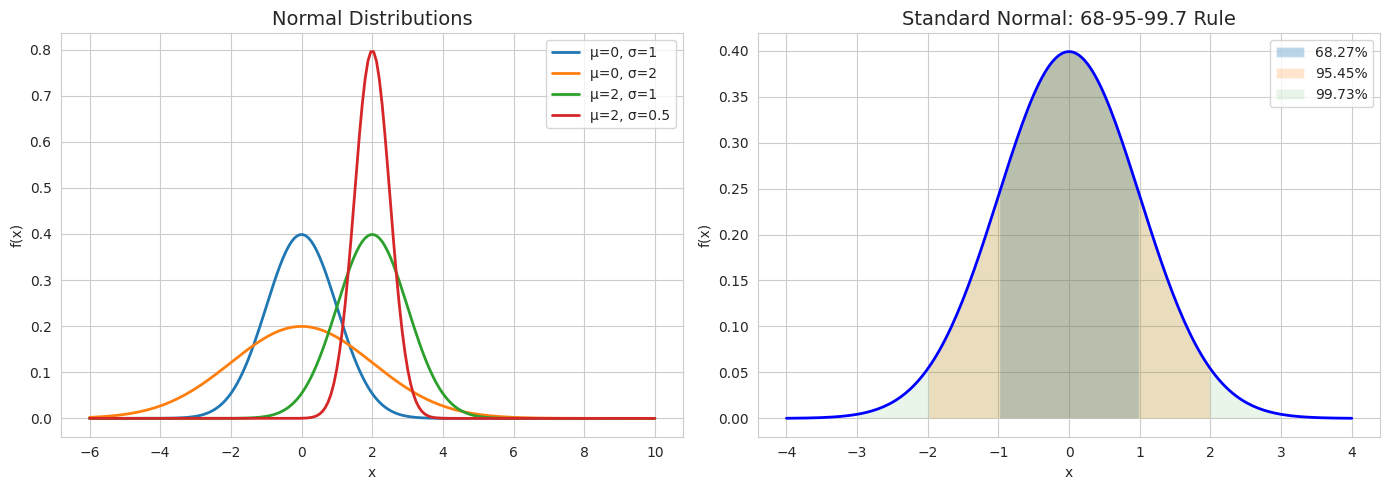

In [2]:
# 正規分布の可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.linspace(-6, 10, 200)

# 異なるパラメータ
params = [(0, 1), (0, 2), (2, 1), (2, 0.5)]
for mu, sigma in params:
    pdf = stats.norm.pdf(x, mu, sigma)
    axes[0].plot(x, pdf, label=f'μ={mu}, σ={sigma}', linewidth=2)

axes[0].set_title('Normal Distributions', fontsize=14)
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].legend()

# 標準正規分布と確率
x = np.linspace(-4, 4, 200)
pdf = stats.norm.pdf(x, 0, 1)
axes[1].plot(x, pdf, 'b-', linewidth=2)
axes[1].fill_between(x, pdf, where=(x >= -1) & (x <= 1), alpha=0.3, label='68.27%')
axes[1].fill_between(x, pdf, where=(x >= -2) & (x <= 2), alpha=0.2, label='95.45%')
axes[1].fill_between(x, pdf, where=(x >= -3) & (x <= 3), alpha=0.1, label='99.73%')

axes[1].set_title('Standard Normal: 68-95-99.7 Rule', fontsize=14)
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6.2 指数分布とガンマ分布

### 指数分布 Exp(λ)
- $f(x) = \lambda e^{-\lambda x}$, $x \geq 0$
- $E[X] = 1/\lambda$, $Var(X) = 1/\lambda^2$
- 無記憶性を持つ

### ガンマ分布 Gamma(α, β)
- $f(x) = \frac{\beta^\alpha}{\Gamma(\alpha)} x^{\alpha-1} e^{-\beta x}$
- $E[X] = \alpha/\beta$, $Var(X) = \alpha/\beta^2$
- 指数分布はα=1のガンマ分布

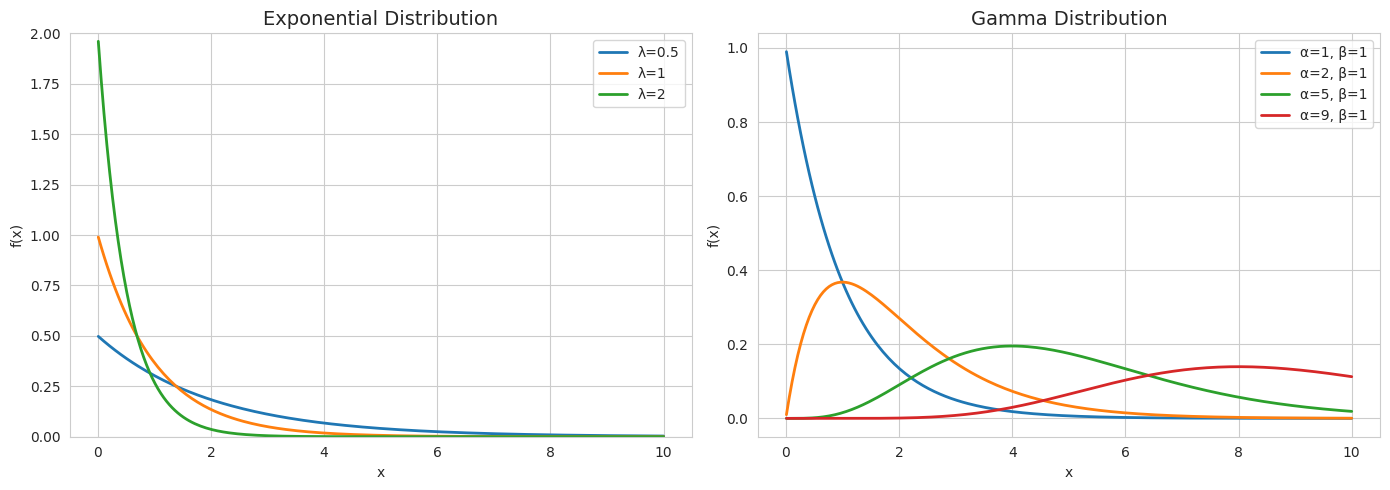

In [3]:
# 指数分布とガンマ分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.linspace(0.01, 10, 200)

# 指数分布
for lam in [0.5, 1, 2]:
    pdf = stats.expon.pdf(x, scale=1/lam)
    axes[0].plot(x, pdf, label=f'λ={lam}', linewidth=2)

axes[0].set_title('Exponential Distribution', fontsize=14)
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].legend()
axes[0].set_ylim(0, 2)

# ガンマ分布
for alpha in [1, 2, 5, 9]:
    pdf = stats.gamma.pdf(x, alpha, scale=1)
    axes[1].plot(x, pdf, label=f'α={alpha}, β=1', linewidth=2)

axes[1].set_title('Gamma Distribution', fontsize=14)
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6.3 カイ二乗分布

### 定義
$Z_1, ..., Z_n \sim$ iid $N(0, 1)$ のとき:
$$\chi^2_n = \sum_{i=1}^n Z_i^2 \sim \chi^2(n)$$

### 性質
- $\chi^2(n) = Gamma(n/2, 1/2)$
- $E[\chi^2_n] = n$, $Var(\chi^2_n) = 2n$
- 加法性: $\chi^2_{m} + \chi^2_{n} \sim \chi^2_{m+n}$

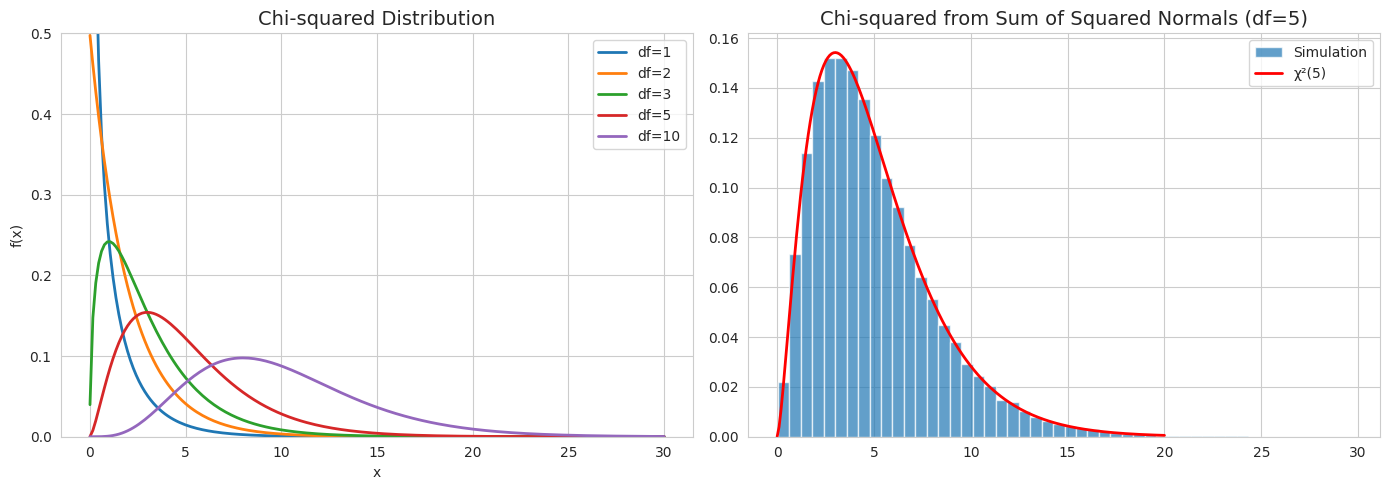

In [4]:
# カイ二乗分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.linspace(0.01, 30, 200)

# 異なる自由度
for df in [1, 2, 3, 5, 10]:
    pdf = stats.chi2.pdf(x, df)
    axes[0].plot(x, pdf, label=f'df={df}', linewidth=2)

axes[0].set_title('Chi-squared Distribution', fontsize=14)
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].legend()
axes[0].set_ylim(0, 0.5)

# シミュレーションによる確認
n_samples = 100000
df = 5

# 標準正規の二乗和
Z = np.random.standard_normal((n_samples, df))
chi2_sim = np.sum(Z**2, axis=1)

axes[1].hist(chi2_sim, bins=50, density=True, alpha=0.7, label='Simulation')
x_range = np.linspace(0, 20, 200)
axes[1].plot(x_range, stats.chi2.pdf(x_range, df), 'r-', linewidth=2, label=f'χ²({df})')

axes[1].set_title(f'Chi-squared from Sum of Squared Normals (df={df})', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

## 6.4 t分布

### 定義
$Z \sim N(0, 1)$, $V \sim \chi^2(n)$ が独立のとき:
$$T = \frac{Z}{\sqrt{V/n}} \sim t(n)$$

### 性質
- 正規分布より裾が重い
- $n \to \infty$ で $N(0, 1)$ に収束
- $E[T] = 0$ (n > 1), $Var(T) = n/(n-2)$ (n > 2)

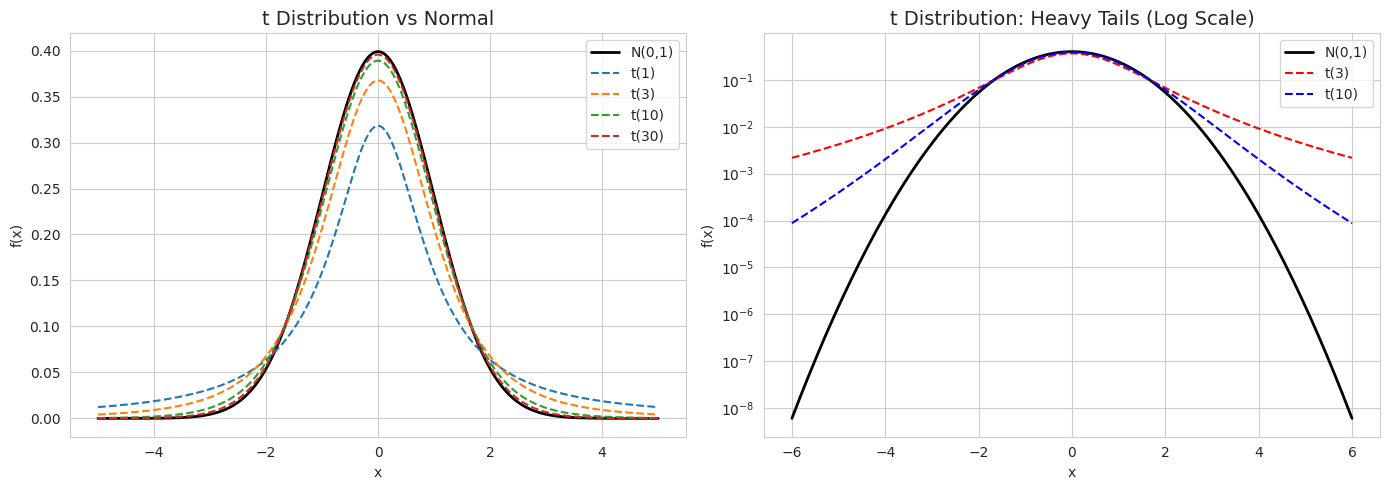

In [5]:
# t分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.linspace(-5, 5, 200)

# 異なる自由度と正規分布との比較
axes[0].plot(x, stats.norm.pdf(x), 'k-', linewidth=2, label='N(0,1)')
for df in [1, 3, 10, 30]:
    pdf = stats.t.pdf(x, df)
    axes[0].plot(x, pdf, '--', label=f't({df})', linewidth=1.5)

axes[0].set_title('t Distribution vs Normal', fontsize=14)
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].legend()

# 裾の重さの比較（対数スケール）
x = np.linspace(-6, 6, 200)
axes[1].semilogy(x, stats.norm.pdf(x), 'k-', linewidth=2, label='N(0,1)')
axes[1].semilogy(x, stats.t.pdf(x, 3), 'r--', linewidth=1.5, label='t(3)')
axes[1].semilogy(x, stats.t.pdf(x, 10), 'b--', linewidth=1.5, label='t(10)')

axes[1].set_title('t Distribution: Heavy Tails (Log Scale)', fontsize=14)
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6.5 F分布

### 定義
$U \sim \chi^2(m)$, $V \sim \chi^2(n)$ が独立のとき:
$$F = \frac{U/m}{V/n} \sim F(m, n)$$

### 性質
- $E[F] = n/(n-2)$ (n > 2)
- $1/F \sim F(n, m)$
- $t(n)^2 = F(1, n)$

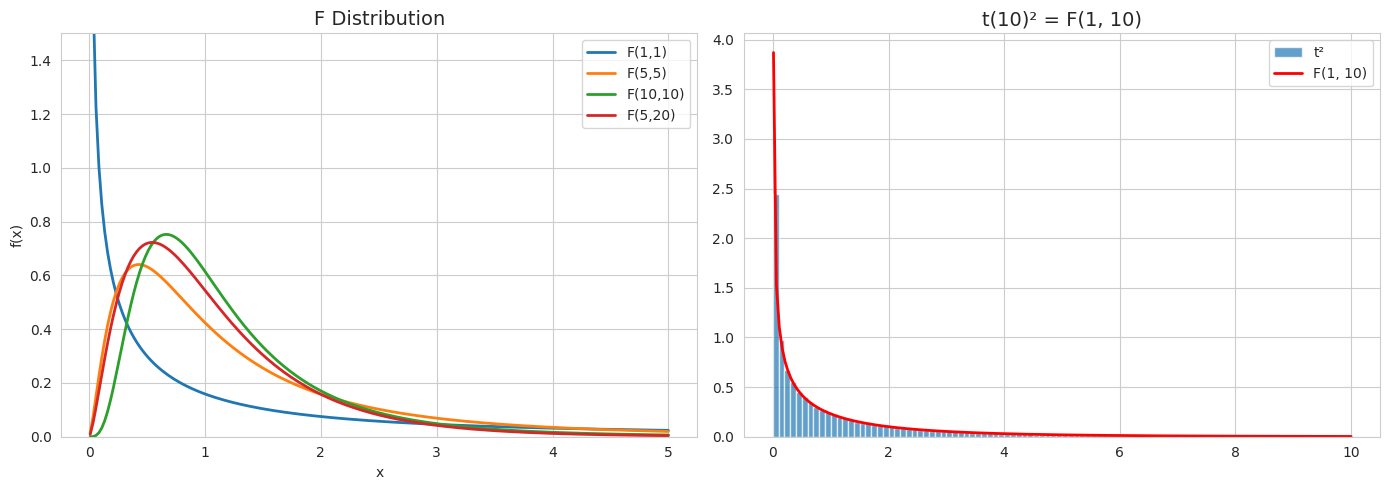

In [6]:
# F分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.linspace(0.01, 5, 200)

# 異なる自由度
df_pairs = [(1, 1), (5, 5), (10, 10), (5, 20)]
for m, n in df_pairs:
    pdf = stats.f.pdf(x, m, n)
    axes[0].plot(x, pdf, label=f'F({m},{n})', linewidth=2)

axes[0].set_title('F Distribution', fontsize=14)
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].legend()
axes[0].set_ylim(0, 1.5)

# t²とFの関係
n_samples = 100000
df = 10

t_samples = np.random.standard_t(df, n_samples)
t_squared = t_samples**2

axes[1].hist(t_squared, bins=100, density=True, alpha=0.7, range=(0, 10), label='t²')
x_range = np.linspace(0.01, 10, 200)
axes[1].plot(x_range, stats.f.pdf(x_range, 1, df), 'r-', linewidth=2, label=f'F(1, {df})')

axes[1].set_title(f't({df})² = F(1, {df})', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

## 6.6 その他の重要な連続分布

### ベータ分布 Beta(α, β)
- $f(x) = \frac{x^{\alpha-1}(1-x)^{\beta-1}}{B(\alpha, \beta)}$, $0 < x < 1$
- $E[X] = \alpha/(\alpha+\beta)$

### ワイブル分布
- 信頼性工学で使用

### 対数正規分布
- $\log X \sim N(\mu, \sigma^2)$

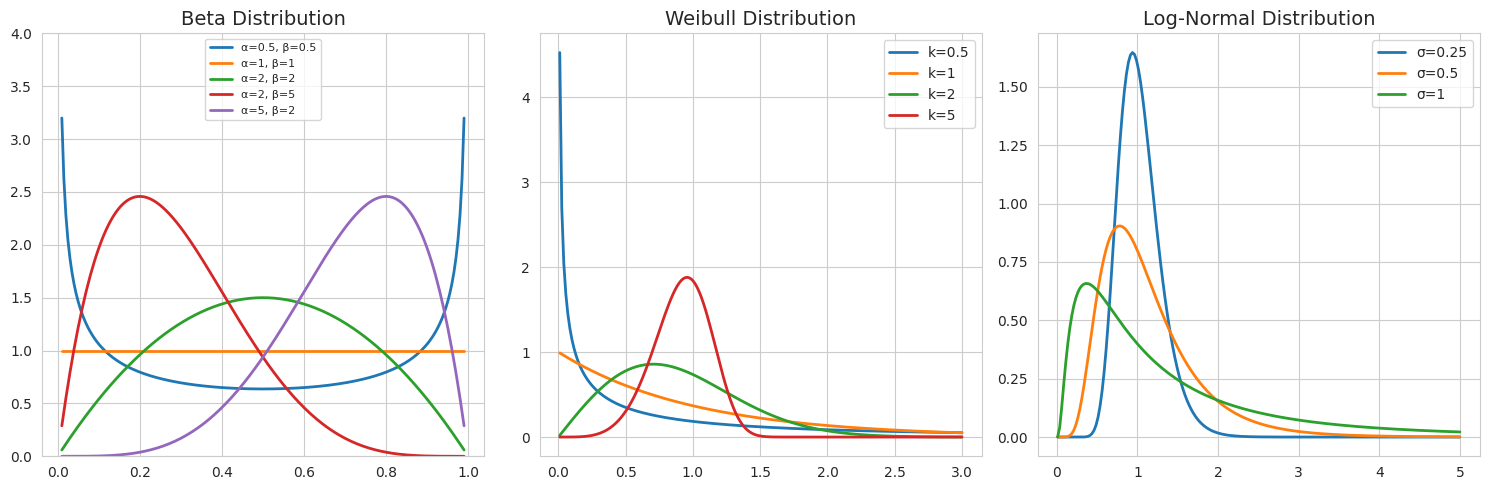

In [7]:
# その他の連続分布
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ベータ分布
x = np.linspace(0.01, 0.99, 200)
params = [(0.5, 0.5), (1, 1), (2, 2), (2, 5), (5, 2)]
for a, b in params:
    pdf = stats.beta.pdf(x, a, b)
    axes[0].plot(x, pdf, label=f'α={a}, β={b}', linewidth=2)

axes[0].set_title('Beta Distribution', fontsize=14)
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 4)

# ワイブル分布
x = np.linspace(0.01, 3, 200)
for k in [0.5, 1, 2, 5]:
    pdf = stats.weibull_min.pdf(x, k)
    axes[1].plot(x, pdf, label=f'k={k}', linewidth=2)

axes[1].set_title('Weibull Distribution', fontsize=14)
axes[1].legend()

# 対数正規分布
x = np.linspace(0.01, 5, 200)
for sigma in [0.25, 0.5, 1]:
    pdf = stats.lognorm.pdf(x, sigma)
    axes[2].plot(x, pdf, label=f'σ={sigma}', linewidth=2)

axes[2].set_title('Log-Normal Distribution', fontsize=14)
axes[2].legend()

plt.tight_layout()
plt.show()

## 6.7 標本分布

### 標本平均の分布
$X_1, ..., X_n \sim$ iid with $E[X_i] = \mu$, $Var(X_i) = \sigma^2$ のとき:
$$\bar{X} = \frac{1}{n}\sum_{i=1}^n X_i$$
- $E[\bar{X}] = \mu$
- $Var(\bar{X}) = \sigma^2/n$

### 標本分散
$$S^2 = \frac{1}{n-1}\sum_{i=1}^n (X_i - \bar{X})^2$$
- $E[S^2] = \sigma^2$（不偏性）

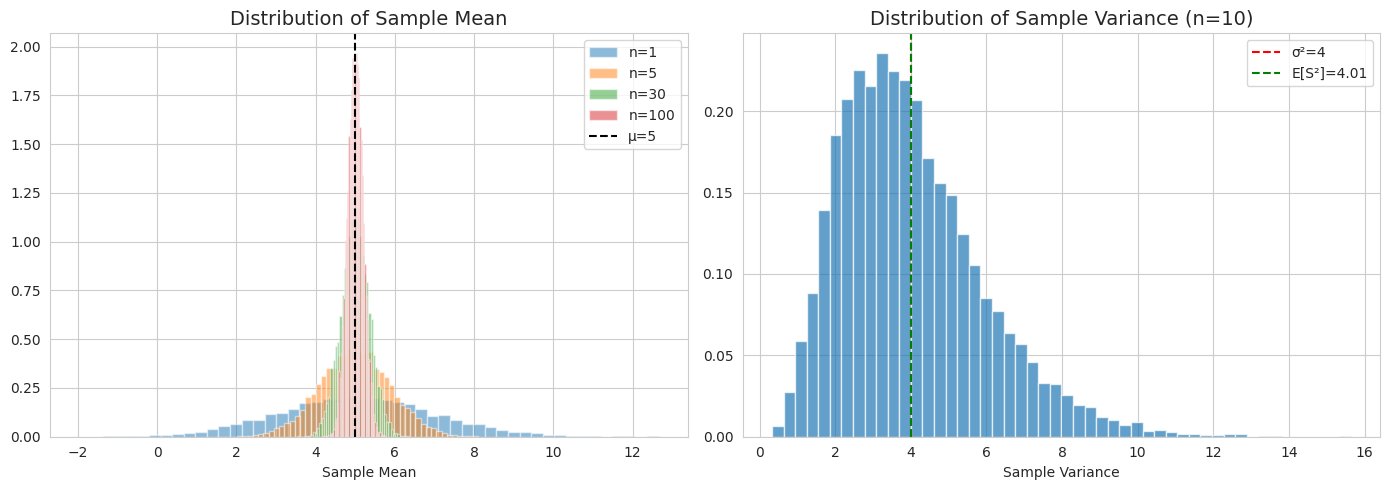

In [8]:
# 標本平均の分布
n_samples = 10000
true_mu, true_sigma = 5, 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample_sizes = [1, 5, 30, 100]

for n in sample_sizes:
    # n個の標本平均を多数回計算
    sample_means = np.mean(np.random.normal(true_mu, true_sigma, (n_samples, n)), axis=1)
    axes[0].hist(sample_means, bins=50, density=True, alpha=0.5, label=f'n={n}')

axes[0].axvline(true_mu, color='k', linestyle='--', label=f'μ={true_mu}')
axes[0].set_title('Distribution of Sample Mean', fontsize=14)
axes[0].set_xlabel('Sample Mean')
axes[0].legend()

# 標本分散の分布（正規母集団）
n = 10
sample_vars = np.var(np.random.normal(true_mu, true_sigma, (n_samples, n)), axis=1, ddof=1)

axes[1].hist(sample_vars, bins=50, density=True, alpha=0.7)
axes[1].axvline(true_sigma**2, color='r', linestyle='--', label=f'σ²={true_sigma**2}')
axes[1].axvline(np.mean(sample_vars), color='g', linestyle='--', 
                label=f'E[S²]={np.mean(sample_vars):.2f}')

axes[1].set_title(f'Distribution of Sample Variance (n={n})', fontsize=14)
axes[1].set_xlabel('Sample Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

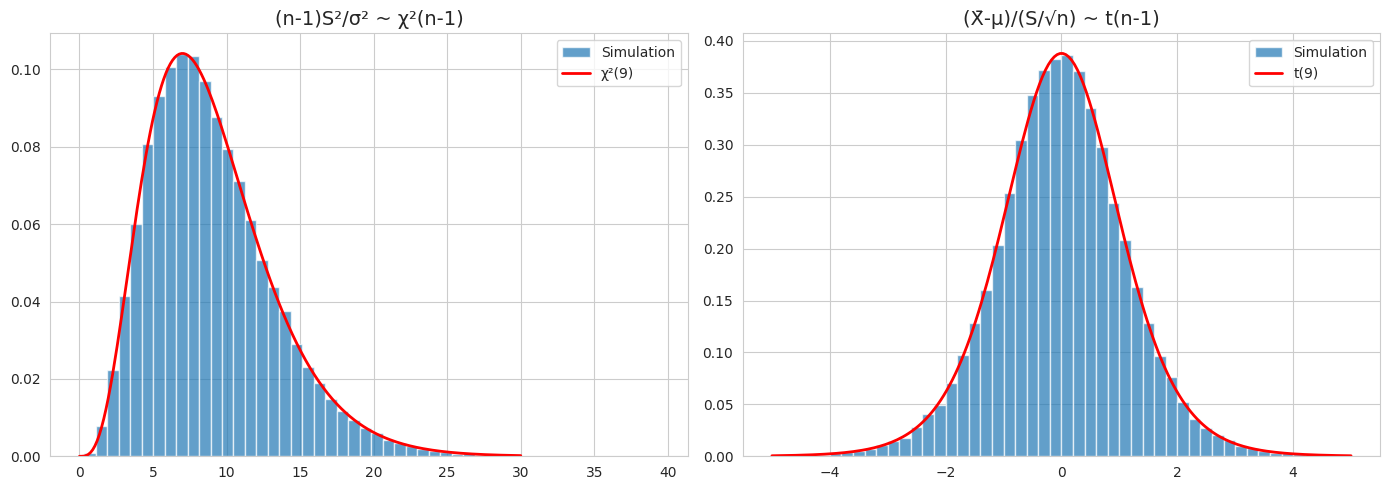

In [9]:
# 正規母集団からの標本分布の重要な関係
n_samples = 100000
n = 10  # 標本サイズ
mu, sigma = 5, 2

# 標本を生成
samples = np.random.normal(mu, sigma, (n_samples, n))
sample_means = np.mean(samples, axis=1)
sample_vars = np.var(samples, axis=1, ddof=1)

# (n-1)S²/σ² ~ χ²(n-1)
chi2_stat = (n - 1) * sample_vars / sigma**2

# (X̄ - μ)/(S/√n) ~ t(n-1)
t_stat = (sample_means - mu) / (np.sqrt(sample_vars) / np.sqrt(n))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# χ² 統計量
axes[0].hist(chi2_stat, bins=50, density=True, alpha=0.7, label='Simulation')
x_range = np.linspace(0, 30, 200)
axes[0].plot(x_range, stats.chi2.pdf(x_range, n-1), 'r-', linewidth=2, 
             label=f'χ²({n-1})')
axes[0].set_title(f'(n-1)S²/σ² ~ χ²(n-1)', fontsize=14)
axes[0].legend()

# t 統計量
axes[1].hist(t_stat, bins=50, density=True, alpha=0.7, range=(-5, 5), label='Simulation')
x_range = np.linspace(-5, 5, 200)
axes[1].plot(x_range, stats.t.pdf(x_range, n-1), 'r-', linewidth=2, 
             label=f't({n-1})')
axes[1].set_title(f'(X̄-μ)/(S/√n) ~ t(n-1)', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

## 6.8 練習問題

### 問題1
$X \sim N(10, 4)$ のとき、$P(8 < X < 13)$ を求めよ。

### 問題2
$X_1, ..., X_{16} \sim$ iid $N(\mu, 9)$ のとき、$\bar{X}$ の分布を求めよ。

### 問題3
$Z_1, ..., Z_5 \sim$ iid $N(0, 1)$ のとき、$\sum_{i=1}^5 Z_i^2$ が10を超える確率を求めよ。

In [10]:
# 問題1の解答
mu, sigma = 10, 2
prob = stats.norm.cdf(13, mu, sigma) - stats.norm.cdf(8, mu, sigma)
print(f"問題1: P(8 < X < 13) = {prob:.4f}")

# 問題2の解答
print(f"\n問題2: X̄ ~ N(μ, 9/16) = N(μ, 0.5625)")

# 問題3の解答
prob3 = 1 - stats.chi2.cdf(10, 5)
print(f"\n問題3: P(χ²(5) > 10) = {prob3:.4f}")

問題1: P(8 < X < 13) = 0.7745

問題2: X̄ ~ N(μ, 9/16) = N(μ, 0.5625)

問題3: P(χ²(5) > 10) = 0.0752


## ⚠️ よくある間違いと解決策

### ❌ 指数分布の無記憶性の誤解
**正しい理解:** P(X>s+t|X>s)=P(X>t)を物理的な寿命に誤適用
**解決策:** 無記憶性は数学的性質で、現実の劣化は考慮しない

### ❌ 正規分布の過度な信頼
**正しい理解:** 全てのデータが正規分布に従うわけではない
**解決策:** QQプロットや検定で正規性を確認

---

## 📝 理解度チェッククイズ

### 問題 1
正規分布N(0,1)の95%点はいくつか？

### 問題 2
指数分布の無記憶性を数式で表せ

---

## 📚 まとめ

お疲れ様でした！この章で学んだ内容は、今後の章で繰り返し使います。

---